Exercise 1: K-Nearest Neighbor

Let us implement the algorithm with the help of the 'Mobile.csv' dataset.

It contains data about customers “Age”, “EstimatedSalary”, “Purchased” .

Download the dataset from the shared folder.


Predict if the customer will purchase a mobile or not.

Load data : mobile.csv

In [85]:
import numpy as numpy
import pandas as pd
# import matplotlib.pyplot as plt

In [86]:
df = pd.read_csv('dataset/mobile.csv')

In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
 2   Purchased        400 non-null    int64
dtypes: int64(3)
memory usage: 9.5 KB


In [88]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [89]:
df.tail()

,Age,EstimatedSalary,Purchased
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0
399,49,36000,1


In [90]:
df["Purchased"].unique()

array([0, 1], dtype=int64)

In [91]:
df.isna().sum()

Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [92]:
purchased_data = df[["Age", "EstimatedSalary", "Purchased"]][df["Purchased"]==1]
purchased_data

,Age,EstimatedSalary,Purchased
7,32,150000,1
16,47,25000,1
17,45,26000,1
18,46,28000,1
19,48,29000,1
...,...,...,...
393,60,42000,1
395,46,41000,1
396,51,23000,1
397,50,20000,1


In [93]:
not_purchased_data = df[["Age", "EstimatedSalary", "Purchased"]][df["Purchased"]==0]
not_purchased_data

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
377,42,53000,0
380,42,64000,0
387,39,71000,0
394,39,59000,0


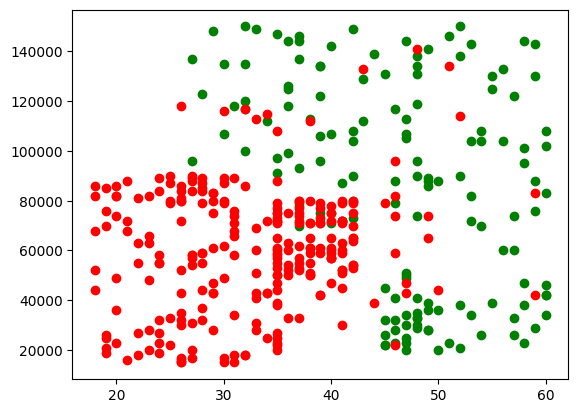

In [94]:
plt.scatter(purchased_data["Age"], purchased_data["EstimatedSalary"], c='green')
plt.scatter(not_purchased_data["Age"], not_purchased_data["EstimatedSalary"], c='red')

In [95]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [96]:
df["Age"].max()

60

In [97]:
df["Age"].min()

18

In [98]:
df["EstimatedSalary"].max()

150000

In [99]:
df["EstimatedSalary"].min()

15000

In [100]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
features_to_scale = ["Age", "EstimatedSalary"]
scaled_values = scaler.fit_transform(df[features_to_scale])


In [101]:
df["norm_age"] = scaled_values[:,0]
df["norm_salary"] = scaled_values[:,1]

In [102]:
df

,Age,EstimatedSalary,Purchased,norm_age,norm_salary
0,19,19000,0,0.023810,0.029630
1,35,20000,0,0.404762,0.037037
2,26,43000,0,0.190476,0.207407
3,27,57000,0,0.214286,0.311111
4,19,76000,0,0.023810,0.451852
...,...,...,...,...,...
395,46,41000,1,0.666667,0.192593
396,51,23000,1,0.785714,0.059259
397,50,20000,1,0.761905,0.037037
398,36,33000,0,0.428571,0.133333


In [103]:
df["norm_age"].min()

0.0

In [104]:
df["norm_age"].max()

0.9999999999999998

In [105]:
X = df[["norm_age", "norm_salary"]]
y = df[["Purchased"]]


In [106]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (320, 2)
Shape of y_train: (320, 1)
Shape of X_test: (80, 2)
Shape of y_test: (80, 1)


In [107]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors=5, metric="euclidean")
model.fit(X_train, y_train)

c:\Users\raghu\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_classification.py:233: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


KNeighborsClassifier(metric='euclidean')

In [108]:
model.score(X_test,y_test) * 100

95.0

In [109]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline

In [110]:
Iris_data = pd.read_csv('Iris.csv')
Iris_data

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [111]:
Iris_data['Species'].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [112]:
v_nv_fn = lambda x: 0 if  x =="versicolor" else 1
Iris_data["v_nv"] = Iris_data["Species"].apply(v_nv_fn)
Iris_data

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,v_nv
0,1,5.1,3.5,1.4,0.2,Iris-setosa,1
1,2,4.9,3.0,1.4,0.2,Iris-setosa,1
2,3,4.7,3.2,1.3,0.2,Iris-setosa,1
3,4,4.6,3.1,1.5,0.2,Iris-setosa,1
4,5,5.0,3.6,1.4,0.2,Iris-setosa,1
...,...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica,1
146,147,6.3,2.5,5.0,1.9,Iris-virginica,1
147,148,6.5,3.0,5.2,2.0,Iris-virginica,1
148,149,6.2,3.4,5.4,2.3,Iris-virginica,1


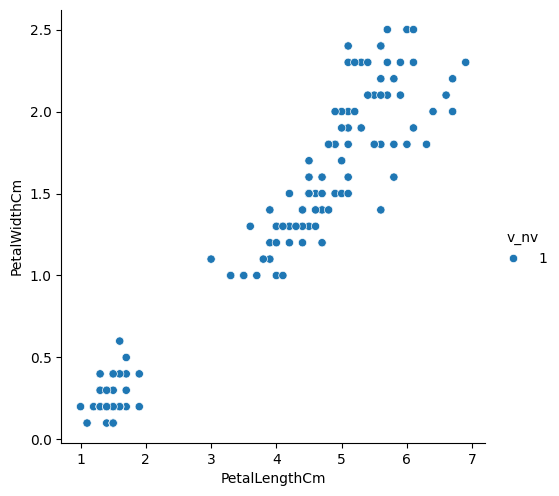

In [113]:
import seaborn as sns
sns.pairplot(
    Iris_data,
    x_vars=["PetalLengthCm"],
    y_vars=["PetalWidthCm"],
    hue="v_nv",
    height=5
)


In [115]:
from sklearn.svm import SVC
X = Iris_data[["PetalLengthCm","PetalWidthCm"]]
y = Iris_data["v_nv"]
model = SVC()
model.fit(X,y)
model.score(X,y)*100

ValueError: The number of classes has to be greater than one; got 1 class

In [ ]:
from mlxtend.plotting import plot_decision_regions
features = np.array(X)
target = np.array(y)
plot_decision_regions(features,target,clf=model)
plt.xlabel("petal length")
plt.ylabel("petal width")
plt.title("decision boundary of SVM on iris dataset")

ModuleNotFoundError: No module named 'mlxtend'

In [116]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
iris_data['Species'] = le.fit_transform(iris_data['Species'])
iris_data

NameError: name 'iris_data' is not defined